# SAM3 Segmentation on ROMER Lab Dataset
**Goal**: Test SAM3 text-prompt segmentation on our own RGB-D captures, extract depth, and generate meshes.

**Dataset**: `dataset2/` — 21 RGB-D pairs captured in the ROMER lab.
- `rgb/00000.png` … `rgb/00020.png` (1280×720, RGB)
- `depth/00000.png` … `depth/00020.png` (1280×720, 16-bit)
- `metadata.json` — per-frame: `depth_scale`, `camera_position_m`, `camera_rotation_rad`, `plane`

In [1]:
import os
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "dataset2")

# Load metadata
with open(os.path.join(DATA_DIR, "metadata.json")) as f:
    metadata = json.load(f)

# Load all image pairs
samples = []
for entry in metadata:
    idx = entry["index"]
    fname = f"{idx:05d}.png"
    samples.append({
        "rgb": Image.open(os.path.join(DATA_DIR, "rgb", fname)),
        "depth": Image.open(os.path.join(DATA_DIR, "depth", fname)),
        "depth_scale": entry["depth_scale"],
        "camera_position_m": entry["camera_position_m"],
        "camera_rotation_rad": entry["camera_rotation_rad"],
        "plane": entry["plane"],
        "index": idx,
    })

print(f"Loaded {len(samples)} RGB-D pairs from {DATA_DIR}")
print(f"Image size: {samples[0]['rgb'].size}, Depth mode: {samples[0]['depth'].mode}")

Loaded 21 RGB-D pairs from /home/cagolinux/Package1_segment_depth/dataset2
Image size: (1280, 720), Depth mode: I;16


## Explore the dataset
Visualize a few RGB + depth pairs side by side.

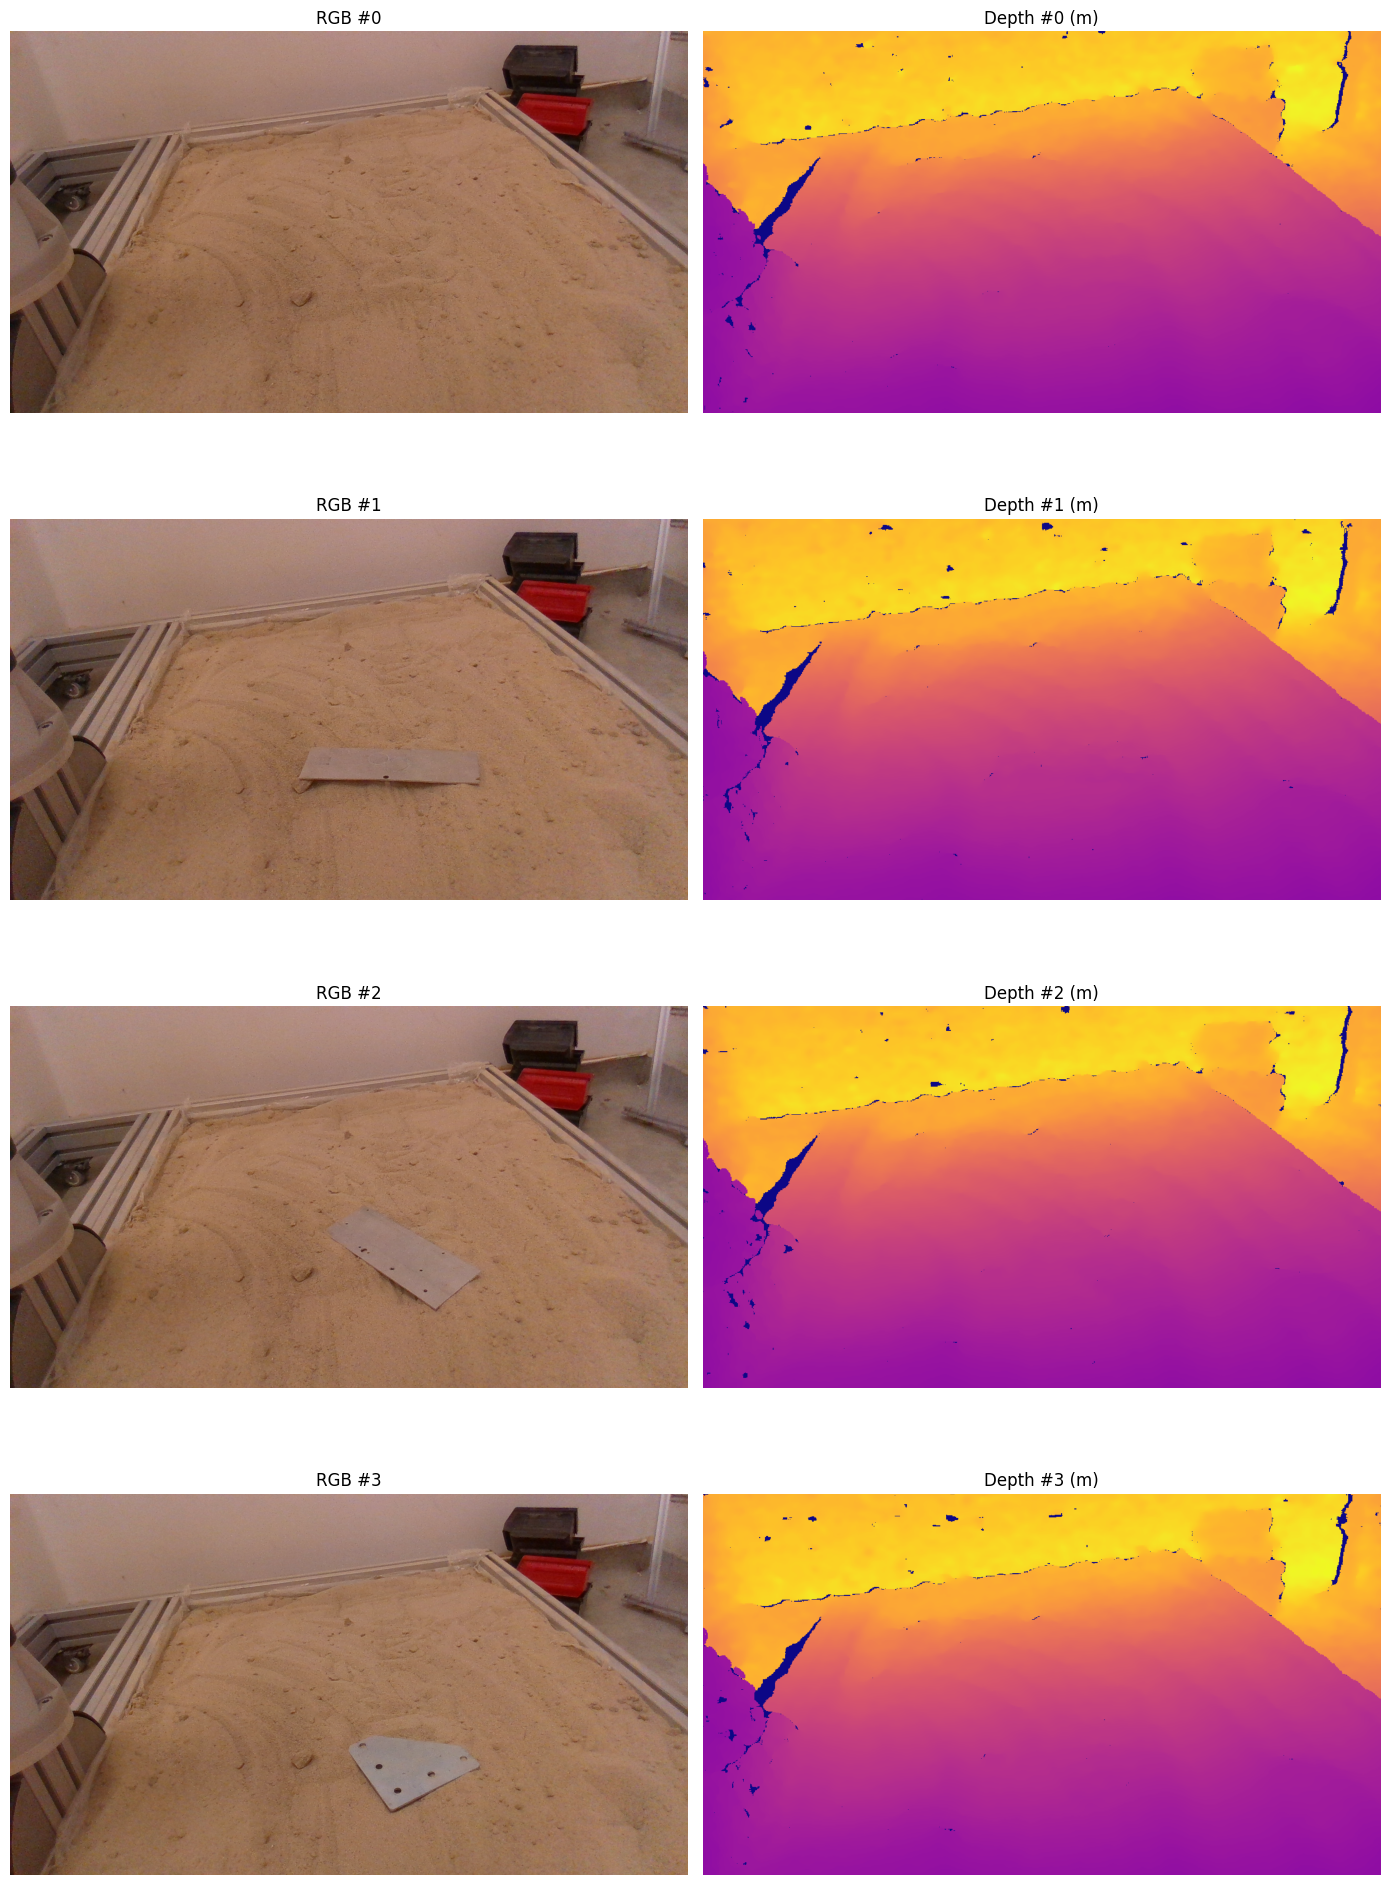

In [2]:
# Show first 4 samples: RGB + depth
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
for i in range(4):
    s = samples[i]
    depth_arr = np.array(s['depth']).astype(np.float64) * s['depth_scale']
    axes[i, 0].imshow(s['rgb']); axes[i, 0].set_title(f"RGB #{s['index']}")
    axes[i, 1].imshow(depth_arr, cmap='plasma'); axes[i, 1].set_title(f"Depth #{s['index']} (m)")
    axes[i, 0].axis('off'); axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

## Load SAM3 Model
Reuse the patched SAM3 loader (fixes the bfloat16 fused kernel issue).

In [3]:
from huggingface_hub import login
login()

In [4]:
import torch
from huggingface_hub import hf_hub_download
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# Patch the fused addmm_act kernel to keep float32 consistency
import sam3.perflib.fused as _fused
import sam3.model.vitdet as _vitdet

def _addmm_act_float32(activation, linear, mat1):
    """Fallback addmm+activation that stays in float32."""
    out = torch.nn.functional.linear(mat1, linear.weight, linear.bias)
    if activation in [torch.nn.functional.gelu, torch.nn.GELU]:
        return torch.nn.functional.gelu(out)
    elif activation in [torch.nn.functional.relu, torch.nn.ReLU]:
        return torch.nn.functional.relu(out)
    raise ValueError(f"Unexpected activation {activation}")

_fused.addmm_act = _addmm_act_float32
_vitdet.addmm_act = _addmm_act_float32

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

cfg_path = hf_hub_download(repo_id="facebook/sam3", filename="config.json")
ckpt_path = hf_hub_download(repo_id="facebook/sam3", filename="sam3.pt")

model = build_sam3_image_model(checkpoint_path=ckpt_path, device=device)
processor = Sam3Processor(model)
processor.confidence_threshold = 0.1  # lower to catch weaker detections
print(f"SAM3 loaded on {device} (confidence_threshold={processor.confidence_threshold})")

/home/cagolinux/Package1_segment_depth/.venv/lib/python3.12/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/cagolinux/Package1_segment_depth/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Using device: cuda
SAM3 loaded on cuda (confidence_threshold=0.1)


## Experiment with Different Text Prompts
Run SAM3 on the same image with various prompts to understand what the model detects.

In [27]:
# --- CONFIG: change these to experiment ---
SAMPLE_IDX = 9                          # which image to test
PROMPTS = [
    "object",
    "metal part",
    "industrial metal part",
    "metal surface",
    "tool",
    "workpiece",
]
# ------------------------------------------

sample = samples[SAMPLE_IDX]
rgb_pil = sample['rgb']

results = {}
with torch.inference_mode():
    inference_state = processor.set_image(rgb_pil)
    for prompt in PROMPTS:
        output = processor.set_text_prompt(state=inference_state, prompt=prompt)
        scores = output["scores"].cpu().numpy()
        masks = output["masks"].cpu().numpy()    # [N, 1, H, W]
        boxes = output["boxes"].cpu().numpy()
        results[prompt] = {"scores": scores, "masks": masks, "boxes": boxes}
        print(f"'{prompt}': {len(scores)} detection(s)" +
              (f", best score={scores.max():.3f}" if len(scores) > 0 else ""))

'object': 15 detection(s), best score=0.351
'metal part': 78 detection(s), best score=0.900
'industrial metal part': 63 detection(s), best score=0.829
'metal surface': 82 detection(s), best score=0.926
'tool': 8 detection(s), best score=0.363
'workpiece': 0 detection(s)


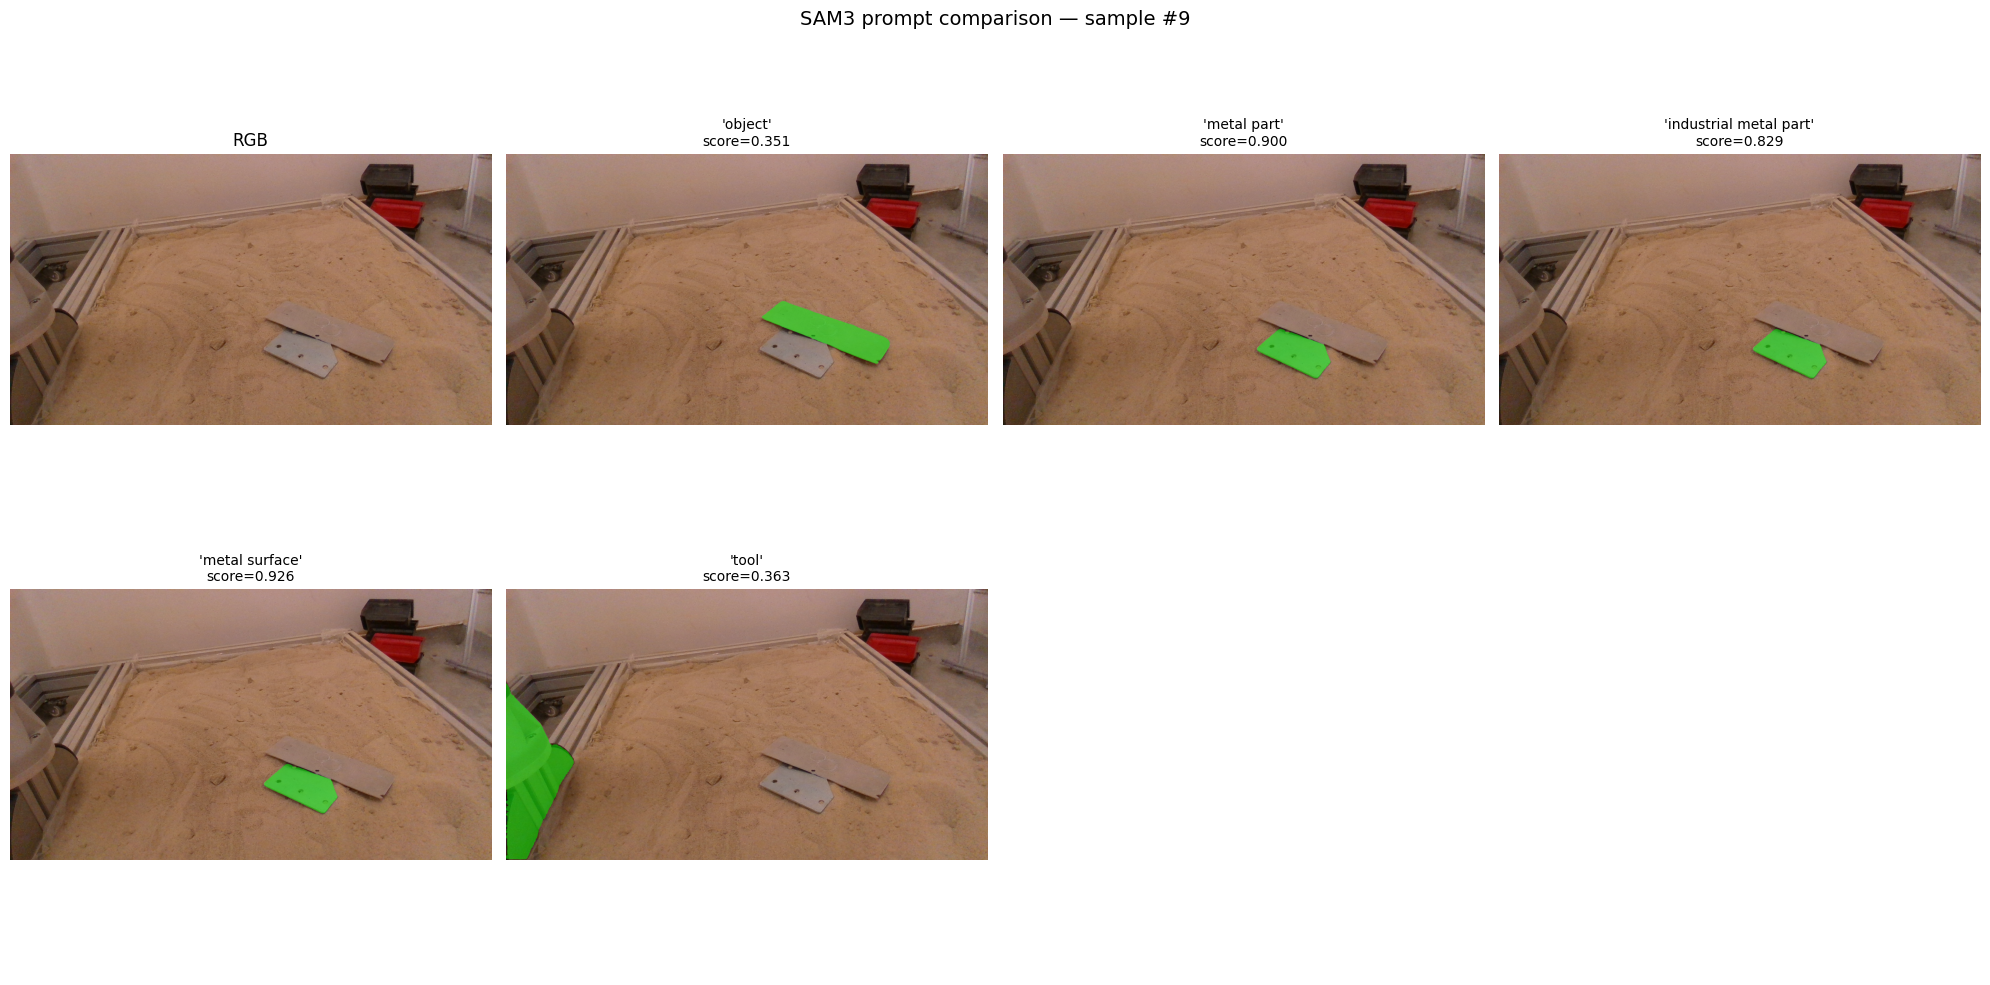

In [28]:
# Visualize best mask per prompt side by side
active_prompts = [p for p in PROMPTS if len(results[p]["scores"]) > 0]
#active_prompts = ["metal surface"]

n = len(active_prompts)
if n == 0:
    print("No detections for any prompt — try different prompts or lower processor.confidence_threshold")
else:
    cols = min(n + 1, 4)
    rows = 1 + (n) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    # First panel: original RGB
    axes[0].imshow(rgb_pil); axes[0].set_title("RGB"); axes[0].axis('off')

    for i, prompt in enumerate(active_prompts):
        r = results[prompt]
        best = np.argmax(r["scores"])
        mask_2d = r["masks"][best].squeeze().astype(bool)
        overlay = np.array(rgb_pil).copy()
        overlay[mask_2d] = (overlay[mask_2d] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"'{prompt}'\nscore={r['scores'][best]:.3f}", fontsize=10)
        axes[i + 1].axis('off')

    # Hide unused axes
    for j in range(n + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"SAM3 prompt comparison — sample #{sample['index']}", fontsize=14)
    plt.tight_layout()
    plt.show()

## Best Prompt → Depth Extraction → Mesh
Pick the best-performing prompt, extract depth under its mask, generate point cloud and mesh.

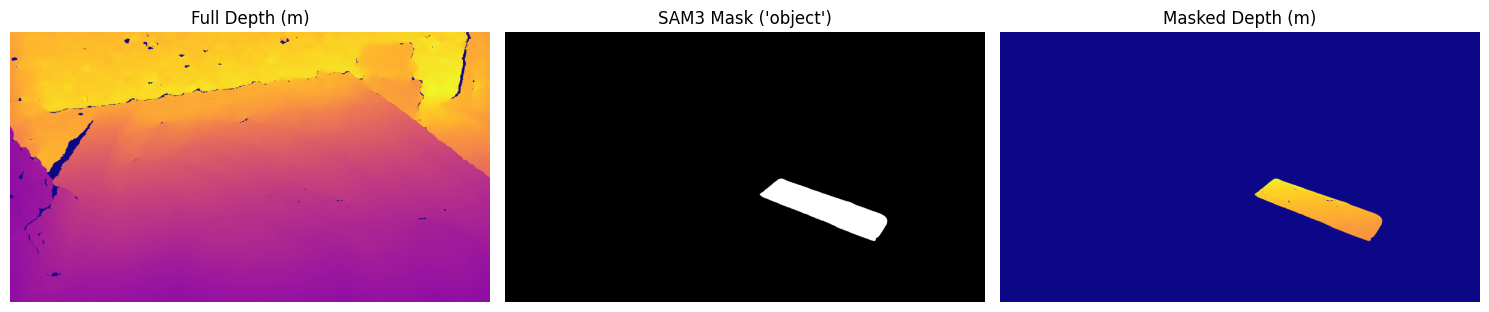

Masked pixels: 22640, depth range: 0.5480m - 0.7310m


In [29]:
# --- CONFIG: pick best prompt from above ---
BEST_PROMPT = active_prompts[0]
# -------------------------------------------

r = results[BEST_PROMPT]
assert len(r["scores"]) > 0, f"No detections for '{BEST_PROMPT}'"
best_idx = np.argmax(r["scores"])
sam3_mask_2d = r["masks"][best_idx].squeeze().astype(bool)

depth_array = np.array(sample['depth']).astype(np.float64)
depth_scale = sample['depth_scale']
masked_depth = depth_array * sam3_mask_2d * depth_scale

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(depth_array * depth_scale, cmap='plasma'); axes[0].set_title("Full Depth (m)")
axes[1].imshow(sam3_mask_2d, cmap='gray'); axes[1].set_title(f"SAM3 Mask ('{BEST_PROMPT}')")
axes[2].imshow(masked_depth, cmap='plasma'); axes[2].set_title("Masked Depth (m)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

valid = masked_depth[masked_depth > 0]
print(f"Masked pixels: {sam3_mask_2d.sum()}, depth range: {valid.min():.4f}m - {valid.max():.4f}m")

In [30]:
import open3d as o3d

# Use a pinhole model — estimate intrinsics from image size if not provided
# RealSense D435i defaults (common lab camera): fx=fy≈640, cx=640, cy=360 for 1280x720
# Adjust these if you know the actual values!
img_w, img_h = sample['rgb'].size
fx = fy = img_w / 2.0   # ~640
cx, cy = img_w / 2.0, img_h / 2.0

print(f"Using estimated intrinsics: fx={fx}, fy={fy}, cx={cx}, cy={cy}")

# Depth → 3D point cloud
v_coords, u_coords = np.where(sam3_mask_2d & (depth_array > 0))
z_vals = depth_array[v_coords, u_coords] * depth_scale

x_vals = (u_coords - cx) * z_vals / fx
y_vals = (v_coords - cy) * z_vals / fy
points = np.stack([x_vals, y_vals, z_vals], axis=-1)

# RGB colors per point
rgb_array = np.array(rgb_pil)
colors = rgb_array[v_coords, u_coords] / 255.0

print(f"Point cloud: {len(points)} points")
print(f"Bounding box: X[{x_vals.min():.3f}, {x_vals.max():.3f}], "
      f"Y[{y_vals.min():.3f}, {y_vals.max():.3f}], Z[{z_vals.min():.3f}, {z_vals.max():.3f}]")

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.01, max_nn=30))
pcd.orient_normals_towards_camera_location(camera_location=np.array([0, 0, 0]))

Using estimated intrinsics: fx=640.0, fy=640.0, cx=640.0, cy=360.0
Point cloud: 22587 points
Bounding box: X[0.041, 0.340], Y[0.035, 0.169], Z[0.548, 0.731]


In [31]:
# Poisson mesh reconstruction
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=9)

# Remove low-density vertices (noisy outliers)
densities = np.asarray(densities)
density_threshold = np.quantile(densities, 0.05)
mesh.remove_vertices_by_mask(densities < density_threshold)

# Crop mesh to point cloud bounding box — Poisson expands beyond the actual data
bbox = pcd.get_axis_aligned_bounding_box()
mesh = mesh.crop(bbox)

print(f"Mesh (cropped): {len(mesh.vertices)} vertices, {len(mesh.triangles)} triangles")

# Save
OUT_DIR = os.path.join(DATA_DIR, "output")
os.makedirs(OUT_DIR, exist_ok=True)
mesh_path = os.path.join(OUT_DIR, f"mesh_{SAMPLE_IDX:05d}.ply")
o3d.io.write_triangle_mesh(mesh_path, mesh)
print(f"Saved to: {mesh_path}")

Mesh (cropped): 50531 vertices, 100516 triangles
Saved to: /home/cagolinux/Package1_segment_depth/dataset2/output/mesh_00009.ply


In [32]:
import plotly.graph_objects as go

vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)
vertex_colors = np.asarray(mesh.vertex_colors) if mesh.has_vertex_colors() else None

# Build color strings for plotly
if vertex_colors is not None:
    colors_rgb = (vertex_colors * 255).astype(np.uint8)
    color_strs = [f"rgb({r},{g},{b})" for r, g, b in colors_rgb]
else:
    color_strs = 'steelblue'

fig = go.Figure(data=[
    go.Mesh3d(
        x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
        i=triangles[:, 0], j=triangles[:, 1], k=triangles[:, 2],
        vertexcolor=color_strs if vertex_colors is not None else None,
        color='steelblue' if vertex_colors is None else None,
        opacity=1.0,
    )
])
fig.update_layout(
    title=f"Mesh — sample #{SAMPLE_IDX}, prompt='{BEST_PROMPT}'",
    scene=dict(
        xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
        aspectmode='data',
    ),
    width=900, height=700,
)
fig.show()

## Project Pipeline Run

This final section runs the reusable `rgbd_sam3` module instead of the ad hoc notebook flow. It writes artifact-backed outputs under `artifacts/sam3_rgbd/` and keeps the earlier exploratory cells intact.

Before running it, make sure the environment has the SAM3 dependencies from `requirements.txt` and that Hugging Face authentication is available if the model weights are not already cached.

In [ ]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Could not locate the project root containing src/.")

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from rgbd_sam3 import DEFAULT_PROMPTS, Sam3RunConfig, run_sam3_rgbd_pipeline

SAM3_PROJECT_PROMPTS = tuple(globals().get("PROMPTS", DEFAULT_PROMPTS))
SAM3_PROJECT_SELECTED_PROMPT = globals().get("BEST_PROMPT")
SAM3_PROJECT_SAMPLE_INDEX = int(globals().get("SAMPLE_IDX", globals().get("SAMPLE_INDEX", 0)))
SAM3_PROJECT_CONFIDENCE_THRESHOLD = float(globals().get("CONFIDENCE_THRESHOLD", 0.1))

sam3_project_config = Sam3RunConfig(
    data_dir=PROJECT_ROOT / "dataset2",
    output_dir=PROJECT_ROOT / "artifacts" / "sam3_rgbd",
    sample_index=SAM3_PROJECT_SAMPLE_INDEX,
    prompts=SAM3_PROJECT_PROMPTS,
    selected_prompt=SAM3_PROJECT_SELECTED_PROMPT,
    confidence_threshold=SAM3_PROJECT_CONFIDENCE_THRESHOLD,
)

sam3_project_result = run_sam3_rgbd_pipeline(sam3_project_config)
print(f"Summary written to: {sam3_project_result['summary_path']}")
print(f"Latest summary written to: {sam3_project_result['latest_summary_path']}")
print(json.dumps(sam3_project_result["summary"], indent=2, sort_keys=True))